<!-- SPDX-FileCopyrightText: 2026 Orbital Research Cluster for Celestial Applications (ORCCA) Lab, University of Colorado at Boulder -->
<!-- SPDX-License-Identifier: ISC -->
# OSIRIS-REx Tutorial Series Pt 2: Media Corrections & Ramp Tables
---
*Scarabaeus | Last revised 2026*

## Objectives
This is the second of a five-part tutorial series that walks through a complete orbit determination (OD) scenario within Scarabaeus (SCB) using real data from the OSIRIS-REx mission. In part two, you will:

- Understand how SCB models tropospheric signal delay using **seasonal** and **non-seasonal** components stored in JSON correction files
- Query tropospheric delays for individual ground stations and arbitrary time spans using `MediaCorrections`
- Evaluate the **Chao elevation mapping function**, which projects the zenith delay to a slant path at a given elevation angle
- Load and inspect DSN **ramp table** records using `RampTableManager`, and compute integrated uplink frequency sensitivity as a function of count interval
- Apply full **round-trip light-time (RTLT) media corrections** to real sequential ranging measurements, converting the path-length error to seconds and Range Units (RU)

## See Also
- [Part 1: Units & Reference Frames](advanced_RealMSR_OSIRIS_REx_OD.ipynb)


## 1.0 — Load SCB and the relevant Python packages

Before doing anything else, import the libraries the tutorial depends on:

- **`scarabaeus`** — the main OD library, aliased to `scb` throughout for brevity.
- **`numpy`** — array mathematics.
- **`pandas`** — tabular data handling, used in Section 4 to parse uplink frequency records.
- **`matplotlib`** — plotting library.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import supplementary as supp
import scarabaeus as scb

kg, km, sec, unitless = scb.Units.get_units(["kg", "km", "sec", "unitless"])
(J2000, ITRF93, ECLIPJ2000, IAUEARTH) = scb.Frame.generate_common_frames()

## 1.1 — Initialize units, frames, and SPICE kernels

### Units and Frames
As in Part 1, physical units are retrieved by name with `scb.Units.get_units()` and reference frames with `scb.Frame.generate_common_frames()`. All three tutorial sections in this notebook use the same unit and frame objects, so they are created once here and reused throughout.

### SPICE Kernels
`scb.SpiceManager.load_kernel_from_mkfile()` furnishes the full set of SPICE kernels for the OSIRIS-REx scenario (SPK trajectories, PCK body constants, LSK leap-second, and frame kernels). A single metakernel file lists them all.

### Ground Stations
Three DSN complexes are used to illustrate how media corrections vary by site:

| Variable | DSN ID | Complex | Location |
|---|---|---|---|
| `GS_C10` | DSS-24 | Goldstone | California, USA |
| `GS_C40` | DSS-35 | Canberra | Australia |
| `GS_C60` | DSS-65 | Madrid | Spain |

Each `scb.GroundStation` object looks up the station's ECEF coordinates and SPICE ID from the loaded kernels.

In [2]:
# load tutorial data
data = supp.load_data()

# load kernels
scb.SpiceManager.clear_kernels()
scb.SpiceManager.load_kernel_from_mkfile(data.OREx_real_data_mk.path)

# Ground stations (one per DSN complex)
GS_C10 = scb.GroundStation("DSS-24")  # Goldstone, California
GS_C40 = scb.GroundStation("DSS-35")  # Canberra, Australia
GS_C60 = scb.GroundStation("DSS-65")  # Madrid, Spain


SCB supplementary data up to date.


---
## 2.0 — Tropospheric Delay Models

Radio signals traveling between a DSN ground station and a deep-space spacecraft must pass through Earth's troposphere. The neutral atmosphere introduces a **non-dispersive path-length delay** that is independent of signal frequency and must be modeled and subtracted from the raw observations before they can be used for orbit determination.

SCB decomposes the zenith tropospheric delay into two additive components stored in separate JSON correction files:

| Component | File | Model function |
|---|---|---|
| **Seasonal** | `1972_001_2048_001_tro_modified.json` | `MediaCorrections.mediafun_trig` — trigonometric annual + semi-annual fit |
| **Non-seasonal** | `2010_001_2010_032_tro.json` | `MediaCorrections.mediafun_nrmpow` — normalized power-law fit |

Both files contain a nested dictionary keyed by site (`C10`, `C40`, `C60`) and wet/dry component (`WET`, `DRY`). The static method `MediaCorrections.get_media_data_for_et()` retrieves the coefficient sub-dictionary that brackets a given epoch.

## 2.1 — Single-station, single-component query

The simplest usage pattern is a single query: one station, one epoch, one component (wet or dry).

`get_media_data_for_et()` returns the coefficient dictionary valid at the query epoch. That dictionary is then passed to the appropriate functional model:

- `mediafun_trig(aux_data, et)` — evaluates the seasonal trigonometric model at `et`, returning a delay in **meters**
- `mediafun_nrmpow(aux_data, et)` — evaluates the non-seasonal normalized power-law model, also in **meters**

In [3]:
# load tutorial data
data = supp.load_data()

# load kernels
scb.SpiceManager.clear_kernels()
scb.SpiceManager.load_kernel_from_mkfile(data.OREx_real_data_mk.path)

# Load tropospheric correction files

tropo_seasonal_path = data.tropo_seasonal_new.path
tropo_nonseasonal_path = data.tropo_nonseasonal.path

#tropo_seasonal_path    = "data/measurements/media_correction/1972_001_2048_001_tro_modified.json"
#tropo_nonseasonal_path = "data/measurements/media_correction/2010_001_2010_032_tro.json"

tropo_seasonal_dict = scb.Utils.load_json(tropo_seasonal_path)
tropo_dict          = scb.Utils.load_json(tropo_nonseasonal_path)

# Query parameters
query_utc      = "2010-01-15 00:07:00 UTC"
query_site     = "C60"   # "C10" | "C40" | "C60"
query_wetordry = "DRY"   # "DRY" | "WET"

# Convert UTC to SPICE ephemeris time
query_et = scb.SpiceManager.utc2et(query_utc)

# Retrieve coefficient sub-dictionaries for the query epoch
aux_seasonal     = scb.MediaCorrections.get_media_data_for_et(
    tropo_seasonal_dict["aux_tropo"], query_site, query_wetordry, query_et
)
aux_non_seasonal = scb.MediaCorrections.get_media_data_for_et(
    tropo_dict["aux_tropo"], query_site, query_wetordry, query_et
)

# Evaluate delay models (result in meters)
delta_m_seasonal     = scb.MediaCorrections.mediafun_trig(aux_seasonal, query_et)
delta_m_non_seasonal = scb.MediaCorrections.mediafun_nrmpow(aux_non_seasonal, query_et)

print(f"Query:              {query_utc}  |  Site: {query_site}  |  Component: {query_wetordry}")
print(f"Seasonal delay:     {delta_m_seasonal:.6f} m")
print(f"Non-seasonal delay: {delta_m_non_seasonal:.6f} m")
print(f"Total zenith delay: {delta_m_seasonal + delta_m_non_seasonal:.6f} m")

SCB supplementary data up to date.
Query:              2010-01-15 00:07:00 UTC  |  Site: C60  |  Component: DRY
Seasonal delay:     2.118438 m
Non-seasonal delay: -0.012684 m
Total zenith delay: 2.105753 m


## 2.2 — Multi-station time-series

In practice, media corrections must be evaluated at every measurement epoch across all active ground stations. The nested loop below sweeps over:

- **Sites** — the three DSN complexes (`C10`, `C40`, `C60`)
- **Wet/dry components** — both the dry (hydrostatic) and wet (water-vapor) parts of the zenith delay
- **Time** — 1 000 evenly spaced epochs spanning January–February 2010

The result arrays `delta_m_seasonal[site, component, time]` and `delta_m_non_seasonal[site, component, time]` hold the zenith delay in meters. A guard (`if aux_data else 0.0`) is included for epochs that fall outside the file's coverage window.

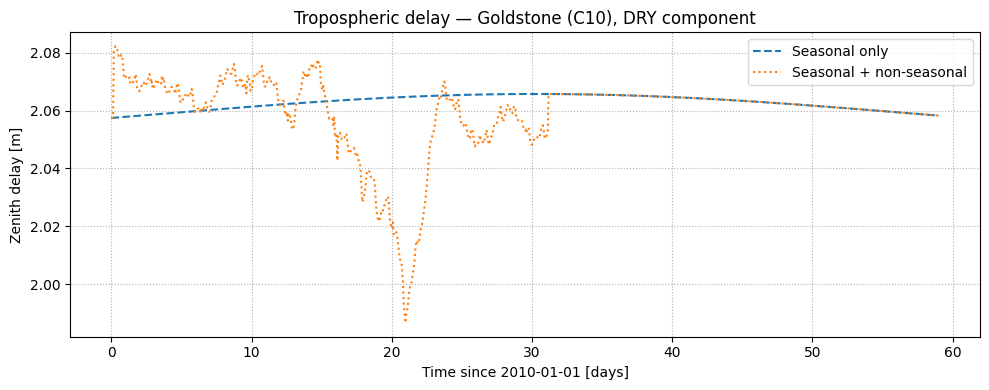

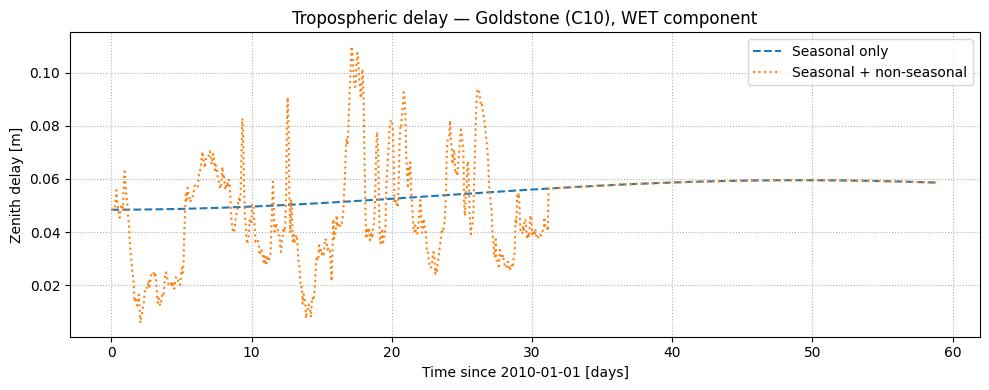

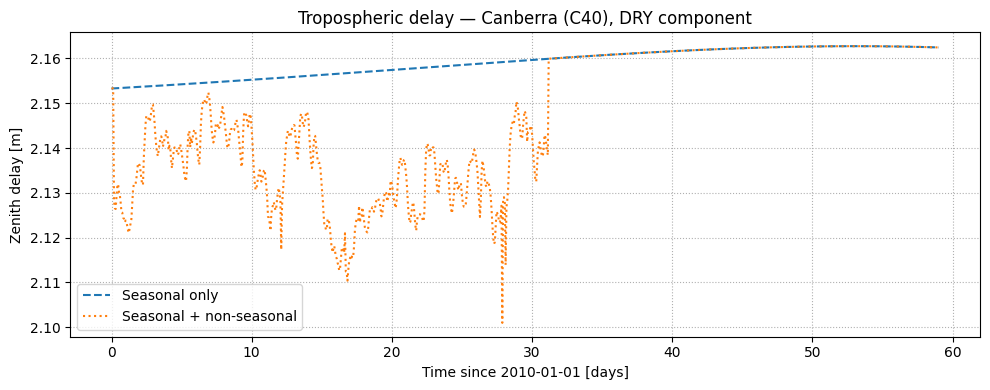

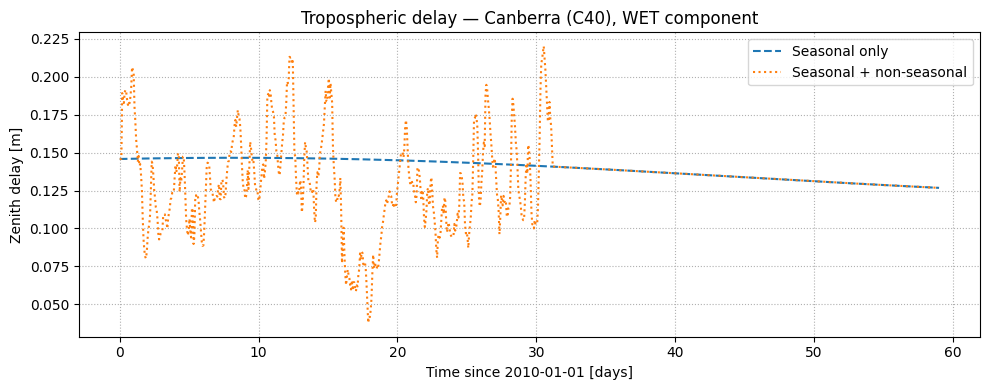

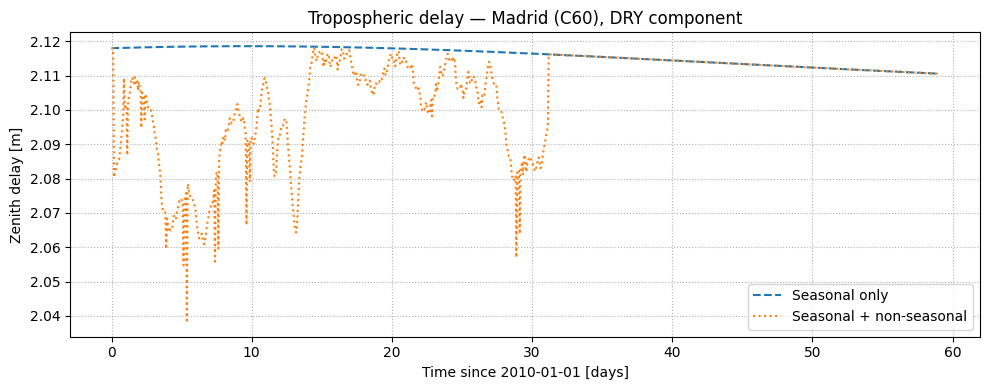

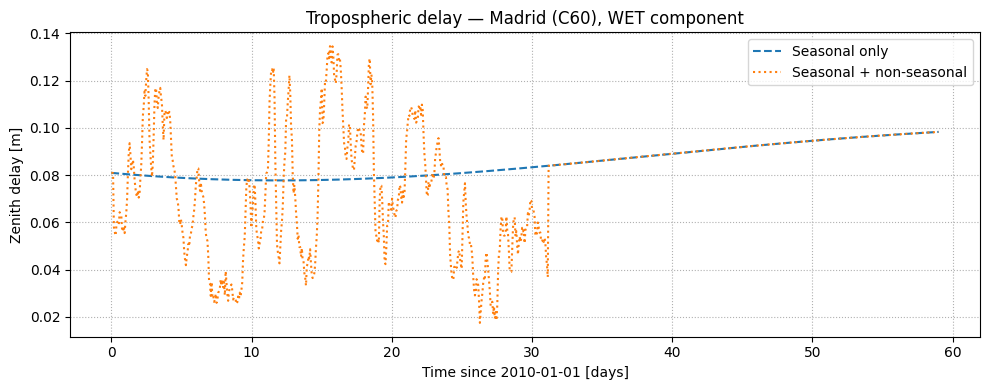

In [4]:
# Time span: Jan 1 – Feb 28, 2010
t_start_et  = scb.SpiceManager.utc2et("2010-01-01 00:00:00 UTC")
t_end_et    = scb.SpiceManager.utc2et("2010-02-28 23:59:00 UTC")
timespan_et = np.linspace(t_start_et, t_end_et, 1000)
timespan_days = (timespan_et - timespan_et[0]) / 86400.0

queries_site    = ["C10", "C40", "C60"]
queries_wetdry  = ["DRY", "WET"]
S, W, T = len(queries_site), len(queries_wetdry), len(timespan_et)

delta_m_seasonal     = np.zeros((S, W, T))
delta_m_non_seasonal = np.zeros((S, W, T))

for si, site in enumerate(queries_site):
    for wi, wd in enumerate(queries_wetdry):
        for ti, et in enumerate(timespan_et):
            aux_s = scb.MediaCorrections.get_media_data_for_et(
                tropo_seasonal_dict["aux_tropo"], site, wd, et
            )
            aux_n = scb.MediaCorrections.get_media_data_for_et(
                tropo_dict["aux_tropo"], site, wd, et
            )
            delta_m_seasonal[si, wi, ti]     = scb.MediaCorrections.mediafun_trig(aux_s, et)     if aux_s else 0.0
            delta_m_non_seasonal[si, wi, ti] = scb.MediaCorrections.mediafun_nrmpow(aux_n, et)   if aux_n else 0.0

# Plot one panel per site × component
site_labels = {"C10": "Goldstone (C10)", "C40": "Canberra (C40)", "C60": "Madrid (C60)"}
for si, site in enumerate(queries_site):
    for wi, wd in enumerate(queries_wetdry):
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(timespan_days, delta_m_seasonal[si, wi, :],
                label="Seasonal only", linestyle="--")
        ax.plot(timespan_days, delta_m_non_seasonal[si, wi, :] + delta_m_seasonal[si, wi, :],
                label="Seasonal + non-seasonal", linestyle=":")
        ax.set_xlabel("Time since 2010-01-01 [days]")
        ax.set_ylabel("Zenith delay [m]")
        ax.set_title(f"Tropospheric delay — {site_labels[site]}, {wd} component")
        ax.grid(True, linestyle=":")
        ax.legend()
        plt.tight_layout()
        plt.show()

## 2.3 — Elevation mapping functions

The zenith delays computed above apply only when the signal travels straight up. For any real ground-station-to-spacecraft link, the signal travels at a slant angle, increasing the path length through the atmosphere. The **mapping function** `m(E)` converts the zenith delay `δ_z` to a slant delay `δ_s`:

```
δ_s = m(E) × δ_z
```

SCB implements the **Chao (1972) mapping function** via `MediaCorrections.chao_mapping(elevation_rad)`, which returns separate dry and wet mapping factors. Both approach 1.0 at zenith (90°) and grow rapidly toward the horizon where the signal path through the atmosphere is longest.

> **Note:** Measurements at very low elevation angles (below ~10°) are typically excluded in OD processing because the mapping function uncertainty becomes large and multipath effects increase.

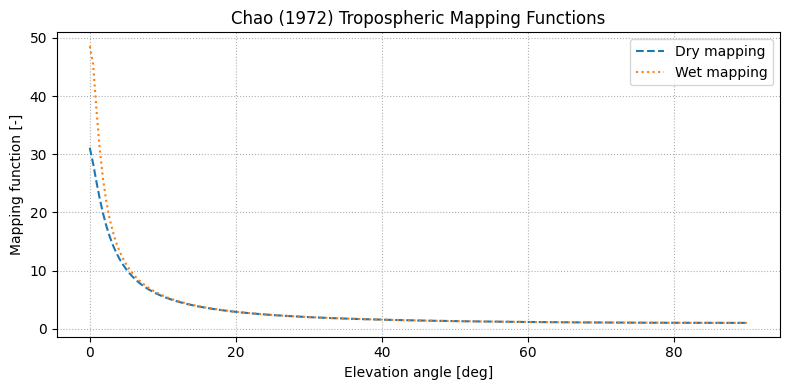

In [5]:
# Evaluate Chao mapping functions over full elevation range
E_rad = np.linspace(0, np.pi / 2, 200)
dry_mapping = np.empty_like(E_rad)
wet_mapping = np.empty_like(E_rad)

for i, el in enumerate(E_rad):
    dry_mapping[i], wet_mapping[i] = scb.MediaCorrections.chao_mapping(el)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.degrees(E_rad), dry_mapping, label="Dry mapping", linestyle="--")
ax.plot(np.degrees(E_rad), wet_mapping, label="Wet mapping", linestyle=":")
ax.set_xlabel("Elevation angle [deg]")
ax.set_ylabel("Mapping function [-]")
ax.set_title("Chao (1972) Tropospheric Mapping Functions")
ax.grid(True, linestyle=":")
ax.legend()
plt.tight_layout()
plt.show()

---
## 3.0 — Ramp Table Manager

DSN uplink signals are not always transmitted at a constant frequency. When a ramp is in effect, the exciter steps through a pre-programmed frequency-vs-time schedule stored in the tracking data as a **ramp table** (SFDU record type 9). Each ramp table entry records:

| Field | Description |
|---|---|
| `sec` | Second-of-day at which the ramp interval begins |
| `doy` | Day-of-year of the ramp interval |
| `ramp_freq` | Exciter frequency at the start of the interval [Hz] |
| `ramp_rate` | Linear frequency rate during the interval [Hz/s] |
| `ramp_type` | Integer flag identifying the ramp mode |

The `scb.RampTableManager.integrate()` method integrates the piecewise-linear frequency profile between two epochs `(t1, t3)` and returns the total accumulated phase, which is needed to correctly compute Doppler and sequential ranging observables when the uplink is ramped.

## 3.1 — Loading and inspecting ramp table data

The ramp table is extracted from the `aux_SFDU_9` block of a standard SCB tracking JSON file. The five fields above are assembled into the `ramp_data` list expected by `RampTableManager.integrate()`.

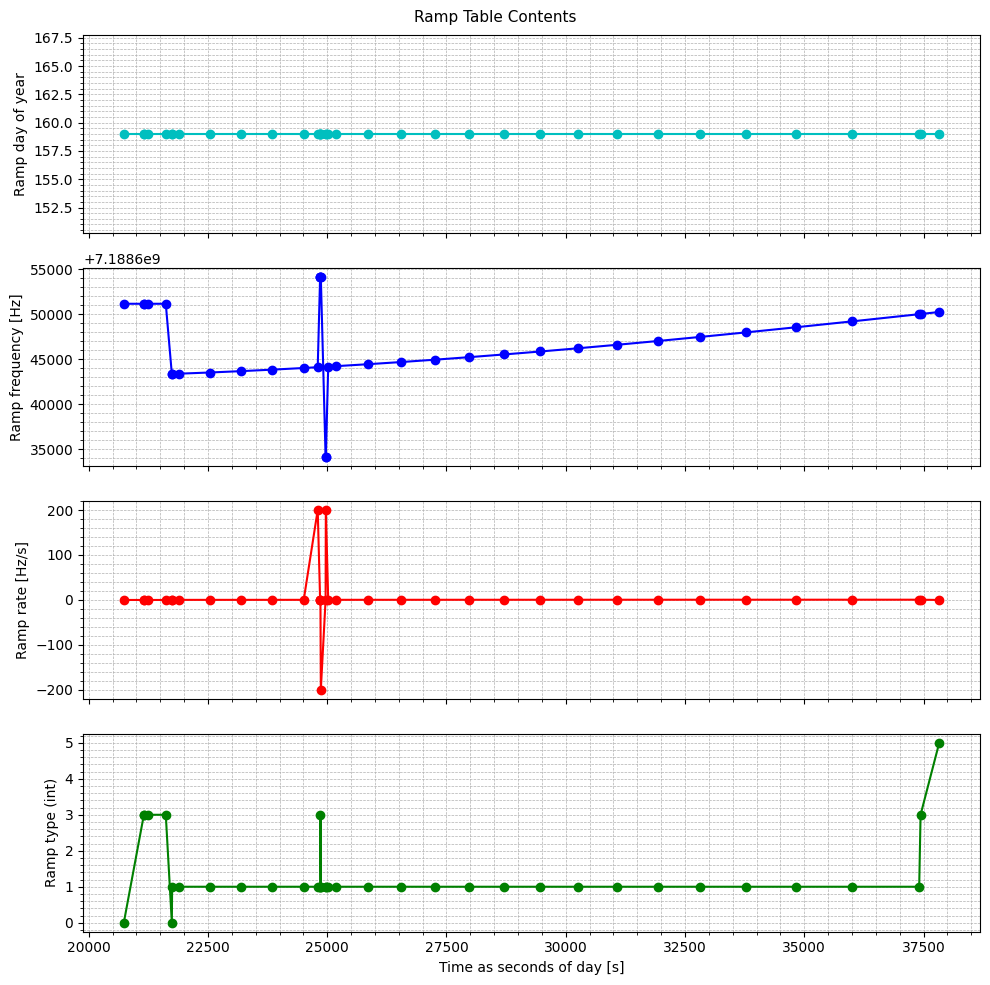

In [6]:
#json_name = "orex_beno_2016_282_122040_2016_282_211501_24"
trk_file_path = data.trk_file.path
trk_data  = scb.Utils.load_json(trk_file_path)

# Assemble ramp table list in the format expected by RampTableManager
ramp_data = [
    trk_data["aux_SFDU_9"]["sec"],
    trk_data["aux_SFDU_9"]["doy"],
    trk_data["aux_SFDU_9"]["ramp_freq"],
    trk_data["aux_SFDU_9"]["ramp_rate"],
    trk_data["aux_SFDU_9"]["ramp_type"],
]

# Visualize the ramp table contents
fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)

axes[0].plot(trk_data["aux_SFDU_9"]["sec"], trk_data["aux_SFDU_9"]["doy"],        "co-")
axes[0].set_ylabel("Ramp day of year")

axes[1].plot(trk_data["aux_SFDU_9"]["sec"], trk_data["aux_SFDU_9"]["ramp_freq"],  "bo-")
axes[1].set_ylabel("Ramp frequency [Hz]")

axes[2].plot(trk_data["aux_SFDU_9"]["sec"], trk_data["aux_SFDU_9"]["ramp_rate"],  "ro-")
axes[2].set_ylabel("Ramp rate [Hz/s]")

axes[3].plot(trk_data["aux_SFDU_9"]["sec"], trk_data["aux_SFDU_9"]["ramp_type"],  "go-")
axes[3].set_ylabel("Ramp type (int)")
axes[3].set_xlabel("Time as seconds of day [s]")

for ax in axes:
    ax.grid(True, which="both", linestyle="--", linewidth=0.5)
    ax.minorticks_on()

fig.suptitle(f"Ramp Table Contents", fontsize=11)
plt.tight_layout()
plt.show()

## 3.2 — Integrated frequency sensitivity

The integrated uplink frequency between times `t1` and `t3` is needed to convert a sequential ranging observable (in Range Units) to a time-of-flight. To understand the sensitivity of that integral to the choice of count interval `Δt = t3 − t1`, we evaluate `RampTableManager.integrate()` at 13 logarithmically spaced offsets from t1 — spanning nanoseconds to thousands of seconds.

The result is scaled by `RU = 0.147530040053405` (the Range Unit conversion factor for this pass), giving the accumulated phase in Range Units as a function of integration length.

> **Key insight:** The log-log plot reveals how quickly the integrated frequency accumulates. A slope of 1 indicates that the frequency is approximately constant over the interval — i.e., the ramp rate is negligible at that timescale.

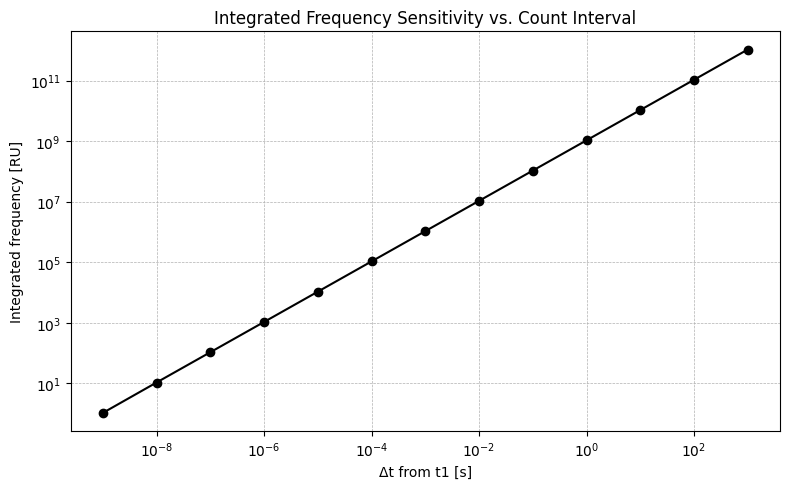

In [7]:
# Hard-coded constants for the orex_beno_2016_282_122040_2016_282_211501_24 pass
RU               = 0.147530040053405   # Range Unit conversion factor
t1_sec           = 48660              # Reference epoch (sec of day)
t1_doy           = 282
t3_doy           = t1_doy
delta_t          = 10 ** np.arange(-9, 4, dtype=float)   # 13 log-spaced offsets [s]
t3_sec_array     = t1_sec + delta_t

f_int_RU = []
for t3_sec in t3_sec_array:
    f_int, _ = scb.RampTableManager.integrate(
        ramp_data, t1_sec, t3_sec, t1_doy, t3_doy
    )
    f_int_RU.append(RU * f_int)

f_int_RU = np.array(f_int_RU)

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(delta_t, f_int_RU, "ko-")
ax.set_xlabel("Δt from t1 [s]")
ax.set_ylabel("Integrated frequency [RU]")
ax.set_title("Integrated Frequency Sensitivity vs. Count Interval")
ax.grid(True, which="both", linestyle="--", linewidth=0.5)
ax.minorticks_on()
plt.tight_layout()
plt.show()

---
## 4.0 — RTLT Media Corrections for Sequential Ranging

In the previous section, we computed the **zenith** tropospheric delay — the path-length error for a signal traveling straight up through the atmosphere. When applying corrections to real measurements, we need the **round-trip light-time (RTLT)** delay, which accounts for both the uplink leg (ground → spacecraft, at transmit time `t1`) and the downlink leg (spacecraft → ground, at receive time `t3`).

The workflow is:

1. Load a tracking data file and identify the ground station
2. Extract the receive epochs `t3` from the sequential ranging observable
3. Compute the transmit epochs `t1` using a quick RTLT estimate from SPICE
4. Evaluate `media_correction.computed_rtlt_delays()` at both `t1` and `t3`
5. Add the two one-way delays to get the total RTLT media correction
6. Convert from meters → seconds (via the speed of light) → Range Units (via the uplink carrier frequency)

This corrected delay is subtracted from the raw sequential ranging observable before it is used in the OD filter.

## 4.1 — Load tracking data and set up the ground station

The tracking file used here is a two-way pass from DSS-24 (Goldstone) acquired on 2017 day-of-year 346. The file contains both the sequential ranging (`2W_sranging`) and Doppler (`2W_doppler`) observables, though only the ranging measurements are processed in this section.

`MediaCorrections` is initialized with a reference to the ground station and the path to the seasonal tropospheric correction file. The non-seasonal file path is resolved later (in Section 4.3) once the exact pass date is known.

In [8]:
trk_file_path          = data.trk_file.path                  #"data/measurements/radiometric/orex_beno_2017_346_093131_2017_346_144501_24.json"
tropo_seasonal_path    = data.tropo_seasonal_new.path        #"data/measurements/media_correction/1972_001_2048_001_tro_modified.json"
tropo_file_bucket      = "data/measurements/media_correction"


# Read tracking data and identify the ground station
trk_data = scb.Utils.load_json(trk_file_path)
DSS_name = "DSS-" + str(trk_data["2W_doppler"]["spice_id"][0])
GS1 = scb.GroundStation(DSS_name)
print("Ground station:", DSS_name)

# Build the uplink frequency array from the ramp table (used for RU conversion)
uplink_carrier_df  = pd.DataFrame.from_dict(trk_data["aux_SFDU_0"], orient="index").transpose()
frequency_values   = pd.Series(uplink_carrier_df["ramp_freq"].reset_index(drop=True))
frequency_array    = scb.ArrayWUnits(np.array(frequency_values), sec**-1)

# Create MediaCorrections object (seasonal file loaded now; non-seasonal set in 4.3)
media_correction = scb.MediaCorrections(
    name="GS1 SRA Media Corrections",
    instrument=GS1,
    tropo_seasonal_file_path=tropo_seasonal_path,
)

# Create the sequential ranging model and extract observed t3 epochs
SRA_model = scb.SequentialRangingReal("GS1 SRA Model", GS1)
SRA_t3, meas_sec, meas_obs, meas_outliers = SRA_model.observed_measurements(
    trk_file_path, meas_name="2W_sranging"
)
print(f"Sequential ranging observations: {len(SRA_t3.times.values)}")

Ground station: DSS-35


Sequential ranging observations: 99


## 4.2 — Compute transmit epochs t1

The sequential ranging observable is tagged at the **receive** time `t3`. The transmit time `t1` (when the uplink tone left the ground station) must be estimated for the uplink media correction. A two-step SPICE light-time computation gives a good approximation:

1. Compute the **downlink** one-way light time at `t3` — the time for the signal to travel from the spacecraft to the ground station.
2. Subtract the downlink light time from `t3` to get the approximate spacecraft time, then compute the **uplink** one-way light time back to the station.
3. The RTLT is the sum of the two, and `t1 = t3 − RTLT`.

In [9]:
target = "-64"   # OSIRIS-REx NAIF ID
frame  = ITRF93

# Downlink one-way light time: spacecraft → ground at t3
dl_rtlt = scb.SpiceManager.get_lighttime(
    trgt_bdy=target,
    epoch_time=SRA_t3.times.values,
    reference_frame=frame.name,
    obsvr_bdy=GS1.name,
    aberration_correction="CN+S",
)

# Uplink one-way light time: ground → spacecraft (at the epoch when signal arrived)
ul_rtlt = scb.SpiceManager.get_lighttime(
    trgt_bdy=GS1.name,
    epoch_time=SRA_t3.times.values - dl_rtlt.values,
    reference_frame=frame.name,
    obsvr_bdy=target,
    aberration_correction="CN+S",
)

rtlt              = ul_rtlt.values + dl_rtlt.values
SRA_t1_array      = SRA_t3.times.values - rtlt
SRA_t1_epoch      = scb.EpochArray(SRA_t1_array, sys="TDB")

print(f"Mean RTLT: {np.mean(rtlt)/60:.2f} min  |  Range: [{np.min(rtlt)/60:.2f}, {np.max(rtlt)/60:.2f}] min")

Mean RTLT: 6.08 min  |  Range: [6.07, 6.08] min


## 4.3 — Resolve the non-seasonal correction file and compute elevation angles

The non-seasonal tropospheric correction file is specific to each year and day-of-year. `MediaCorrections.find_tro_metadata()` scans the correction file bucket and returns the file whose coverage window contains the pass date, which is extracted from the first t3 epoch.

Elevation angles at each t3 epoch are computed with `SpiceManager.get_elevation_angle()`. The elevation angle is needed in Section 4.4 to apply the Chao mapping function, and it is also a useful diagnostic — passes near the horizon (low elevation) have much larger and more uncertain media corrections.

In [10]:
# Find the non-seasonal correction file for this pass
year_q, day_q, _ = scb.SpiceManager.et2YDS([SRA_t3.times.values[0]])
metadata_tropo = scb.MediaCorrections.find_tro_metadata(tropo_file_bucket, year_q[0], day_q[0])
media_correction.tropo_non_seasonal_file_path = os.path.join(
    tropo_file_bucket, metadata_tropo["file"]
)
print("Non-seasonal file:", metadata_tropo["file"])

# Elevation angles at each t3 epoch
rad_unit = scb.Units.get_units(["rad"])
SRA_elevation_angles = []
for et in SRA_t3.times.values:
    el_awu = scb.SpiceManager.get_elevation_angle(
        target=target,
        et=et,
        station=DSS_name,
        abcorr="LT+S",
    )
    el_rad = scb.ArrayWUnits.get_value_in_target_units(el_awu, rad_unit)
    SRA_elevation_angles.append(np.degrees(el_rad))

SRA_elevation_angles = np.array(SRA_elevation_angles)
print(f"Elevation angle range: {SRA_elevation_angles.min():.1f}\u00b0 \u2013 {SRA_elevation_angles.max():.1f}\u00b0")


FileNotFoundError: [Errno 2] No such file or directory: 'data/measurements/media_correction'

## 4.4 — Compute RTLT tropospheric delays

`media_correction.computed_rtlt_delays()` evaluates the full tropospheric model (seasonal + non-seasonal, dry + wet, with Chao mapping applied) at a given ephemeris time and returns the one-way path-length correction in **meters**.

The RTLT correction is the sum of the corrections at `t3` (downlink) and `t1` (uplink):

```
Δp [m]   = Δp(t3) + Δp(t1)
Δτ [s]   = Δp [m] × 10⁻³ / c          (Moyer eq. 10-27, converting km → m → s)
ΔΦ [RU]  = Δτ [s] × f_uplink [Hz]
```

where `c` is the speed of light in km/s from `scb.constants.c`.

In [11]:
SRA_tropo_t3 = []
SRA_tropo_t1 = []

for ii in range(len(SRA_t3.times.values)):
    t3 = SRA_t3.times.values[ii]
    t1 = SRA_t1_epoch.times.values[ii]

    p_t3 = media_correction.computed_rtlt_delays(query_time_et=t3, target_spice_id=target)
    p_t1 = media_correction.computed_rtlt_delays(query_time_et=t1, target_spice_id=target)

    SRA_tropo_t3.append(p_t3)
    SRA_tropo_t1.append(p_t1)

SRA_tropo_t3 = np.array(SRA_tropo_t3)
SRA_tropo_t1 = np.array(SRA_tropo_t1)

# RTLT path-length correction [m]
SRA_delta_m    = SRA_tropo_t3 + SRA_tropo_t1

# Convert to RTLT time correction [s]  (Moyer 10-27: 1e-3 converts m → km)
SRA_delta_rtlt = (1.0 / scb.constants.c.values) * (SRA_delta_m * 1e-3)

# Convert to Range Units
SRA_delta_RU   = SRA_delta_rtlt * frequency_array[0].values

print(f"Mean RTLT tropo correction: {np.mean(SRA_delta_rtlt)*1e6:.3f} μs  /  {np.mean(SRA_delta_RU):.4f} RU")

Mean RTLT tropo correction: 0.000 μs  /  0.0000 RU


## 4.5 — Results and plots

Five plots summarize the media correction output for this pass:

1. **RTLT correction vs time (t3)** — how the total delay evolves over the pass
2. **Path-length correction vs time** — same information in meters
3. **Range Unit correction vs time** — the operationally relevant quantity subtracted from the raw observable
4. **RTLT correction vs elevation angle** — shows the expected increase toward the horizon
5. **Elevation angle vs time** — pass geometry reference

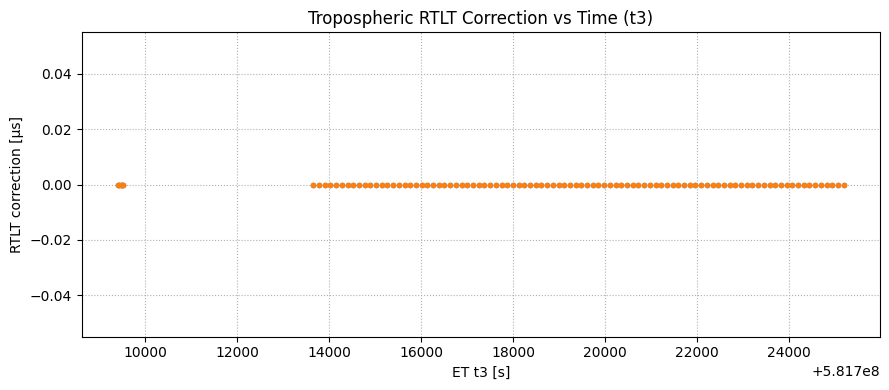

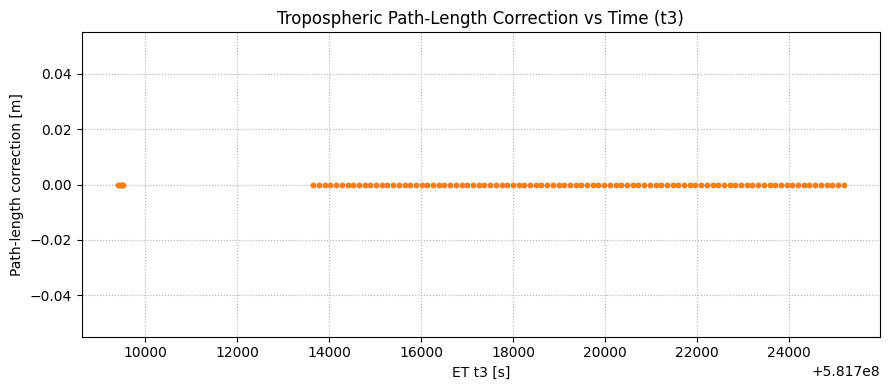

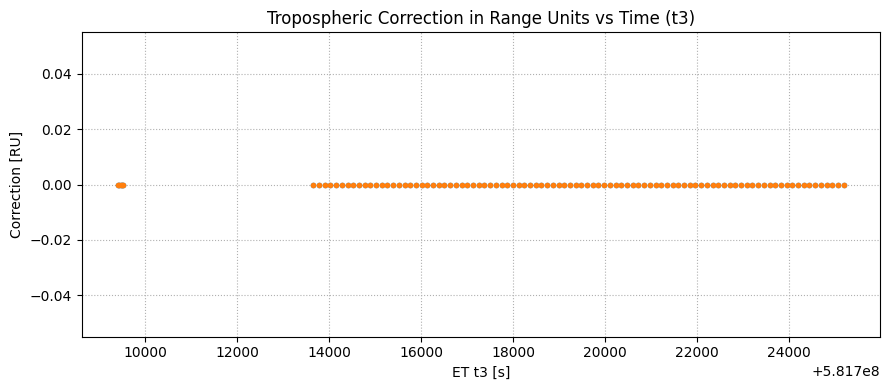

NameError: name 'SRA_elevation_angles' is not defined

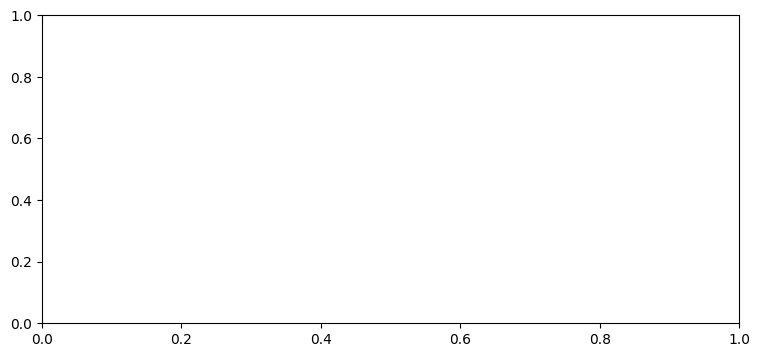

In [12]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(SRA_t3.times.values, SRA_delta_rtlt * 1e6, ".")
ax.set_xlabel("ET t3 [s]")
ax.set_ylabel("RTLT correction [μs]")
ax.set_title("Tropospheric RTLT Correction vs Time (t3)")
ax.grid(True, linestyle=":")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(SRA_t3.times.values, SRA_delta_m, ".")
ax.set_xlabel("ET t3 [s]")
ax.set_ylabel("Path-length correction [m]")
ax.set_title("Tropospheric Path-Length Correction vs Time (t3)")
ax.grid(True, linestyle=":")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(SRA_t3.times.values, SRA_delta_RU, ".")
ax.set_xlabel("ET t3 [s]")
ax.set_ylabel("Correction [RU]")
ax.set_title("Tropospheric Correction in Range Units vs Time (t3)")
ax.grid(True, linestyle=":")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(SRA_elevation_angles, SRA_delta_rtlt * 1e6, ".")
ax.set_xlabel("Elevation angle [deg]")
ax.set_ylabel("RTLT correction [μs]")
ax.set_title("Tropospheric RTLT Correction vs Elevation Angle (at t3)")
ax.grid(True, linestyle=":")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(SRA_t3.times.values, SRA_elevation_angles, ".")
ax.set_xlabel("ET t3 [s]")
ax.set_ylabel("Elevation angle [deg]")
ax.set_title("Ground Station Elevation Angle vs Time (t3)")
ax.grid(True, linestyle=":")
plt.tight_layout()
plt.show()